# Stock Price Trend Prediction with LSTM

**Objective:** use recent daily market history to estimate the next trading session's adjusted closing price.

This notebook downloads adjusted daily prices from Yahoo Finance through `yfinance`, engineers SMA(20), SMA(50), and RSI(14), trains a Keras 3 LSTM to predict a one-session percentage change, and converts that into a closing-price estimate. It evaluates the model on a chronological holdout. The trained weights, scalers, data, metrics, and graphs are saved next to this notebook.

> This is an educational time-series example. Historical-price models cannot anticipate market shocks and are not investment advice.


## 1. Imports and configuration

The project implementation lives in `stock_lstm.py` so the notebook and Streamlit dashboard share the same feature and model code.

In [1]:
import os
os.environ.setdefault("KERAS_BACKEND", "torch")

from pathlib import Path
import sys
import json
import pandas as pd
from IPython.display import display, Image

OUTPUT_DIR = Path.cwd()
if not (OUTPUT_DIR / "stock_lstm.py").exists() and (OUTPUT_DIR / "outputs" / "stock_lstm.py").exists():
    OUTPUT_DIR = OUTPUT_DIR / "outputs"
sys.path.insert(0, str(OUTPUT_DIR.resolve()))

from stock_lstm import fetch_history, add_indicators, prepare_data, build_model, train_pipeline, load_saved_model

TICKER = "AAPL"
PERIOD = "5y"
LOOKBACK = 60


## 2. Fetch daily adjusted price data

`auto_adjust=True` adjusts OHLC prices for splits and dividends. The executed notebook reuses the bundled raw CSV so its run is reproducible and does not need another download. Delete the CSV first if you want to fetch fresh data.

In [2]:
raw_path = OUTPUT_DIR / f"{TICKER}_raw_history.csv"
if raw_path.exists():
    raw = pd.read_csv(raw_path, parse_dates=["Date"], index_col="Date")
else:
    raw = fetch_history(TICKER, PERIOD)
    raw.to_csv(raw_path, index_label="Date")
print(f"Rows: {len(raw):,} | From {raw.index.min().date()} through {raw.index.max().date()}")
display(raw.tail())


Rows: 1,254 | From 2021-09-30 through 2026-09-29


,Open,High,Low,Close,Volume
Date,,,,,
2026-09-23,341.079987,341.799988,335.500000,337.019989,31658800
2026-09-24,336.720001,338.910004,334.299988,335.920013,24733100
2026-09-25,336.040009,341.670013,334.529999,341.070007,30002500
2026-09-28,340.369995,342.989990,338.040009,338.399994,32820800
2026-09-29,336.970001,337.089996,328.700012,329.399994,38427200


## 3. Engineer indicators and inspect the series

The rolling averages and RSI use only current and earlier observations. The first 50 rows are removed because the 50-session SMA needs a warm-up window.

In [3]:
data = add_indicators(raw)
display(data[["Close", "SMA_20", "SMA_50", "RSI_14", "Volume"]].tail())
print(f"Rows after indicator warm-up: {len(data):,}")


,Close,SMA_20,SMA_50,RSI_14,Volume
Date,,,,,
2026-09-23,337.019989,326.948000,321.406815,62.943193,31658800
2026-09-24,335.920013,328.071500,321.580859,61.359815,24733100
2026-09-25,341.070007,329.396001,321.742802,65.709147,30002500
2026-09-28,338.399994,330.331000,321.841754,61.823794,32820800
2026-09-29,329.399994,330.958499,321.903583,50.898702,38427200


Rows after indicator warm-up: 1,205


## 4. Chronological train, validation, and test sequences

Rows are split 70%/15%/15% in time order. Each prediction uses the preceding 60 sessions. The target is next-session percentage change, which is combined with the preceding close to produce a price estimate. Scalers are fit only on training rows; validation and test rows never affect the fitted scaling ranges.

In [4]:
prepared = prepare_data(data, lookback=LOOKBACK)
print(f"Train sequences:      {prepared.train_x.shape}")
print(f"Validation sequences: {prepared.val_x.shape}")
print(f"Test sequences:       {prepared.test_x.shape}")
print(f"Test dates: {prepared.test_dates.min().date()} to {prepared.test_dates.max().date()}")


Train sequences:      (783, 60, 5)
Validation sequences: (181, 60, 5)
Test sequences:       (181, 60, 5)
Test dates: 2026-01-09 to 2026-09-29


## 5. Build the Keras LSTM

The network stacks two LSTM layers with dropout and a small dense head. Keras 3 runs here on its PyTorch backend.

In [5]:
model = build_model(lookback=LOOKBACK, n_features=prepared.train_x.shape[-1])
model.summary()


Model: "daily_stock_close_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 32)         │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,289 (32.38 KB)

 Trainable params: 8,289 (32.38 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train, validate, and evaluate

Early stopping restores the best validation-loss weights. Test predictions are one-step forecasts that use the actual preceding history at each step. A last-close baseline is included for context. Set `RETRAIN = True` to train again; the executed notebook loads the included trained model and saved metrics.

In [6]:
RETRAIN = False
if RETRAIN:
    result = train_pipeline(
        ticker=TICKER,
        period=PERIOD,
        output_dir=OUTPUT_DIR,
        epochs=20,
        batch_size=64,
        verbose=1,
        downloaded_frame=raw,
    )
else:
    model, scaler_bundle = load_saved_model(OUTPUT_DIR, TICKER)
    result = {
        "metrics": json.loads((OUTPUT_DIR / "metrics.json").read_text(encoding="utf-8")),
        "forecast": json.loads((OUTPUT_DIR / "forecast.json").read_text(encoding="utf-8")),
    }
    print("Loaded the included trained weights. Set RETRAIN = True to fit again.")
print("\nChronological test metrics")
display(pd.Series(result["metrics"], name="value"))
print("\nLatest next-session estimate")
display(pd.Series(result["forecast"], name="value"))


Loaded the included trained weights. Set RETRAIN = True to fit again.

Chronological test metrics


C:\Users\M jitendra\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam_1', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(store)


mae                                                                      3.951932
rmse                                                                     5.304072
mape_percent                                                             1.375976
directional_accuracy_percent                                            46.961326
naive_last_close_mae                                                      3.58451
ticker                                                                       AAPL
target                                  next trading session adjusted close (USD)
lookback_sessions                                                              60
feature_columns                 [Daily_Return, SMA_20_Gap, SMA_50_Gap, RSI_14,...
rows_after_indicator_warmup                                                  1205
train_rows                                                                    843
validation_rows                                                               181
test_rows       


Latest next-session estimate


ticker                                                                               AAPL
as_of_date                                                                     2026-09-29
last_adjusted_close                                                            329.399994
next_session_adjusted_close_estimate                                           328.271413
predicted_change_percent                                                        -0.342617
change_percent_vs_last_close                                                    -0.342617
horizon                                 one trading session; one-step forecast using t...
Name: value, dtype: object

## 7. Review the saved graphs

The holdout graph compares model predictions with actual adjusted closes. The other figures show indicator context and training progress.

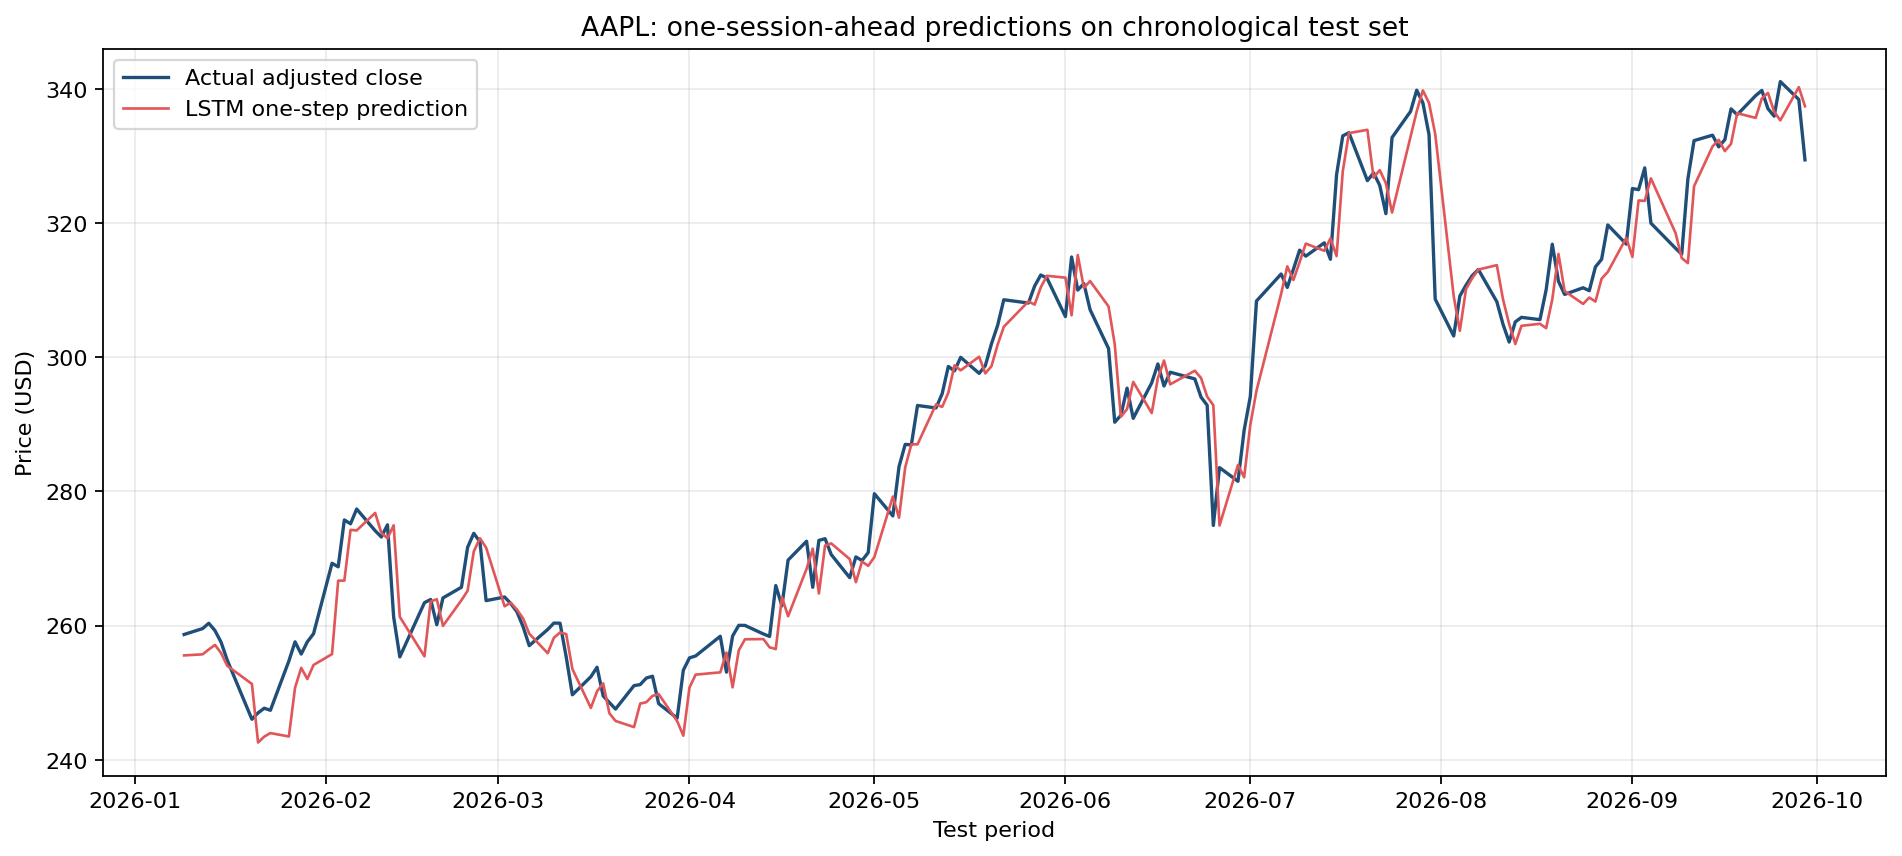

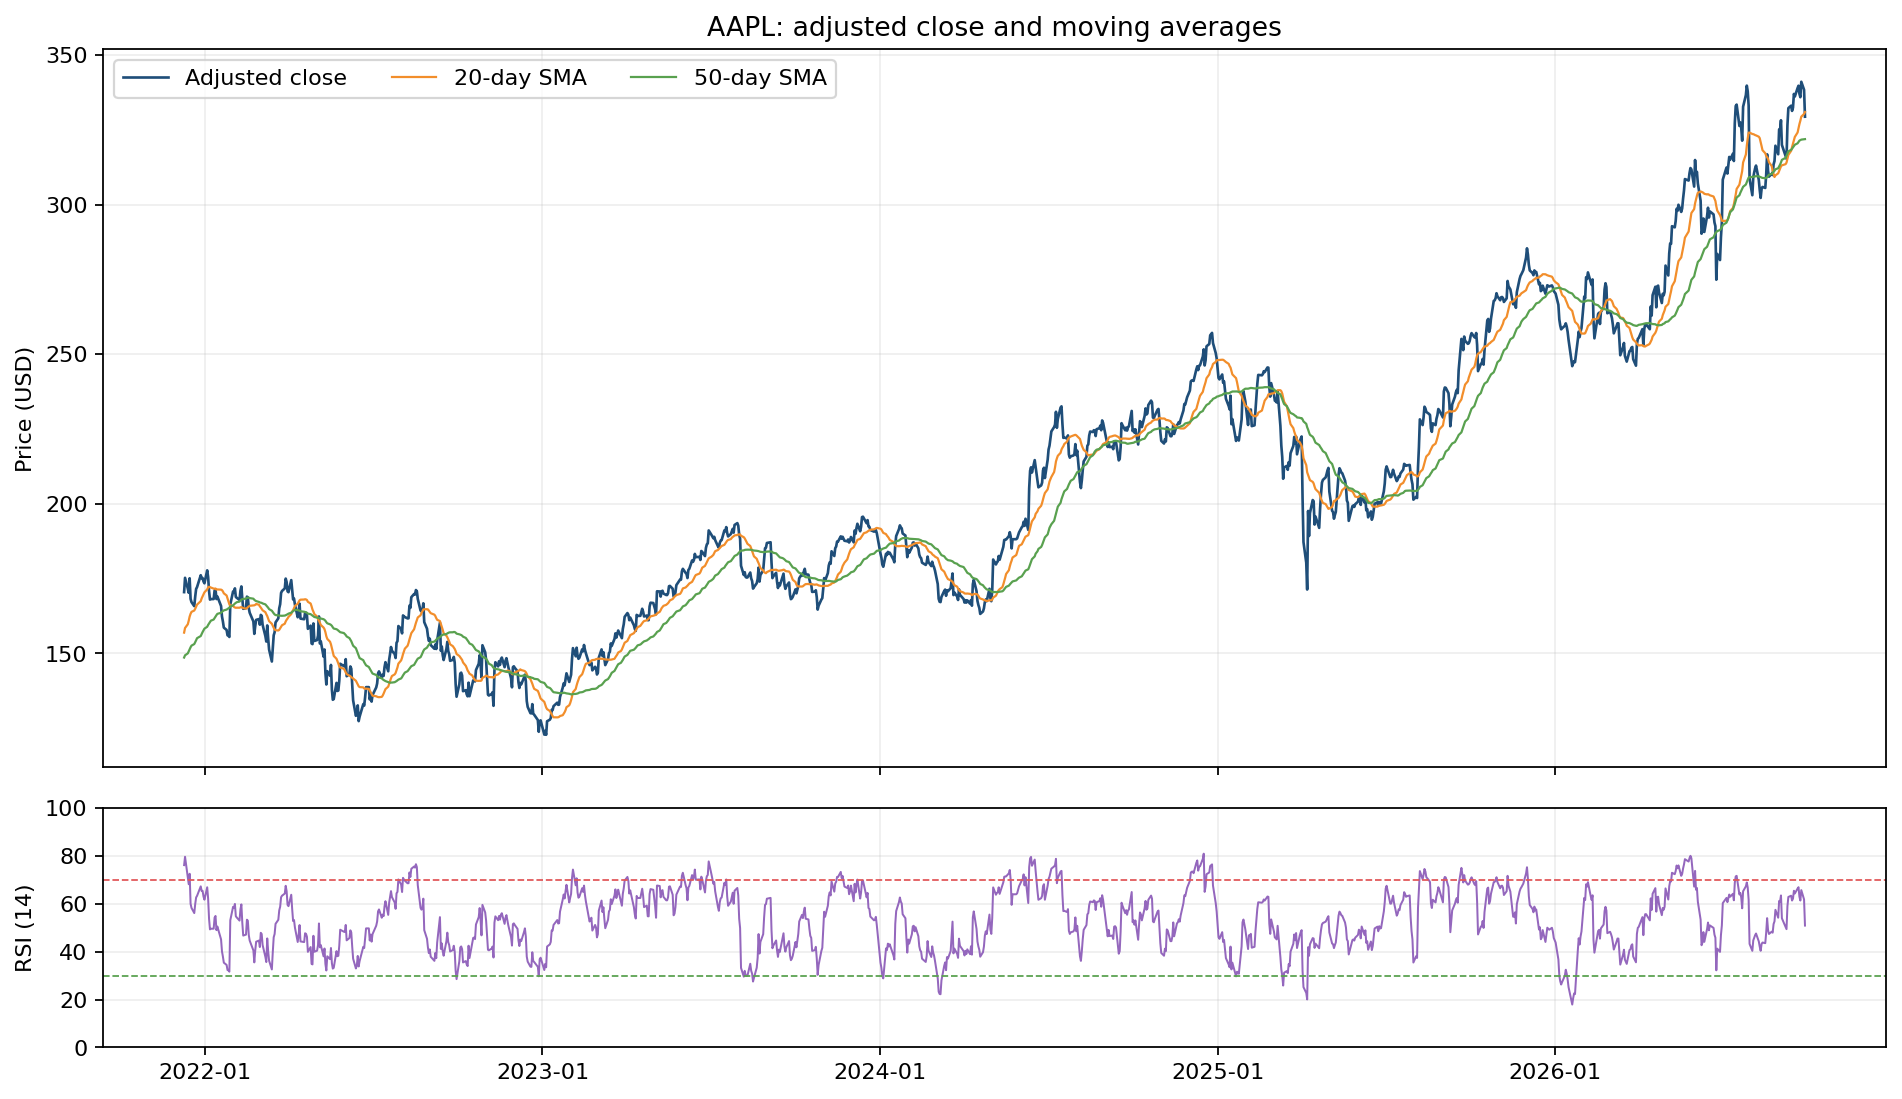

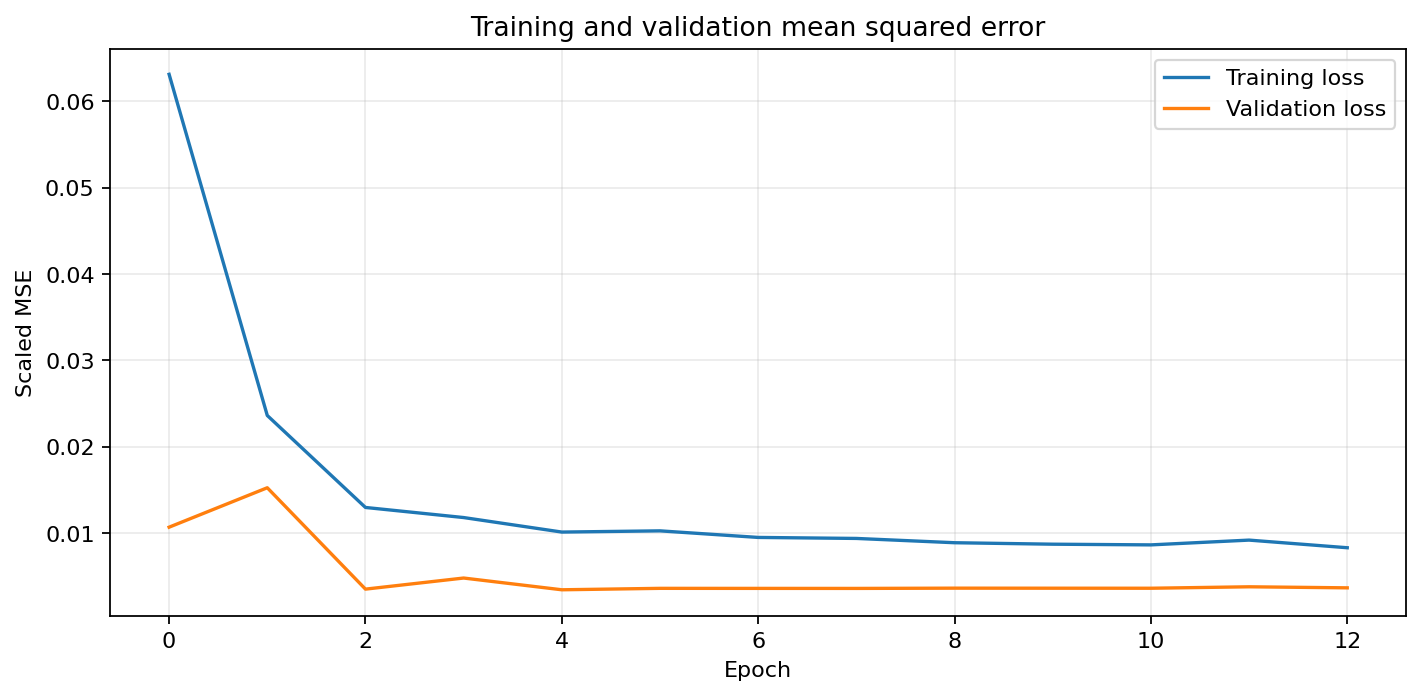

In [7]:
display(Image(filename=str(OUTPUT_DIR / "test_predictions.png")))
display(Image(filename=str(OUTPUT_DIR / "price_indicators.png")))
display(Image(filename=str(OUTPUT_DIR / "training_history.png")))


## 8. Reuse the deliverables

- `AAPL_lstm.weights.h5` contains the trained Keras weights.
- `AAPL_scalers.joblib` contains the exact train-fitted scalers and input metadata needed at inference time.
- `AAPL_history.csv`, `metrics.json`, `forecast.json`, and the PNG charts are generated alongside this notebook.
- Run `streamlit run streamlit_app.py` in this folder for the local dashboard at `http://localhost:8501`.

See `README.md` for the file map, setup commands, evaluation definitions, and limitations.